# Obesity Level Prediction using Machine Learning

## Problem Statement
The objective of this project is to predict obesity levels based on lifestyle and eating habits using machine learning techniques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("obesity_level.csv")
df.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,0be1dad
0,0,Male,24.443011,1.699998,81.669950,1,1,2.000000,2.983297,Sometimes,0,2.763573,0,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,1,1,2.000000,3.000000,Frequently,0,2.000000,0,1.000000,1.000000,0,Automobile,0rmal_Weight
2,2,Female,18.000000,1.711460,50.165754,1,1,1.880534,1.411685,Sometimes,0,1.910378,0,0.866045,1.673584,0,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,1,1,3.000000,3.000000,Sometimes,0,1.674061,0,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,1,1,2.679664,1.971472,Sometimes,0,1.979848,0,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  object 
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  int64  
 6   FAVC                            20758 non-null  int64  
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  object 
 10  SMOKE                           20758 non-null  int64  
 11  CH2O                            20758 non-null  float64
 12  SCC                             

,id,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,SMOKE,CH2O,SCC,FAF,TUE
count,20758.00000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000,20758.000000
mean,10378.50000,23.841804,1.700245,87.887768,0.819636,0.914443,2.445908,2.761332,0.011803,2.029418,0.033096,0.981747,0.616756
std,5992.46278,5.688072,0.087312,26.379443,0.384500,0.279716,0.533218,0.705375,0.108000,0.608467,0.178891,0.838302,0.602113
min,0.00000,14.000000,1.450000,39.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,5189.25000,20.000000,1.631856,66.000000,1.000000,1.000000,2.000000,3.000000,0.000000,1.792022,0.000000,0.008013,0.000000
50%,10378.50000,22.815416,1.700000,84.064875,1.000000,1.000000,2.393837,3.000000,0.000000,2.000000,0.000000,1.000000,0.573887
75%,15567.75000,26.000000,1.762887,111.600553,1.000000,1.000000,3.000000,3.000000,0.000000,2.549617,0.000000,1.587406,1.000000
max,20757.00000,61.000000,1.975663,165.057269,1.000000,1.000000,3.000000,4.000000,1.000000,3.000000,1.000000,3.000000,2.000000


## Target Variable Explanation

0 → Insufficient Weight  
1 → Normal Weight  
2 → Overweight I  
3 → Overweight II  
4 → Obesity I  
5 → Obesity II  
6 → Obesity III  

In [10]:
df['Obesity_Label'] = df['0be1dad']

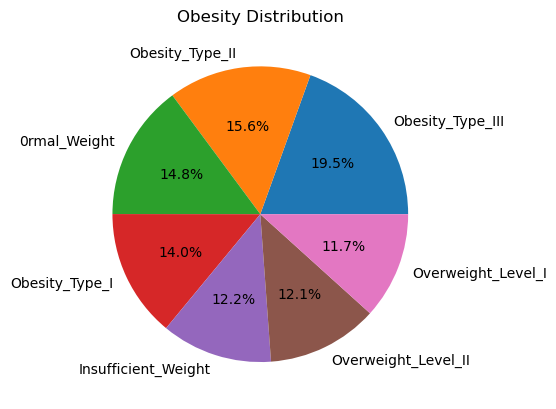

In [11]:
df['Obesity_Label'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Obesity Distribution")
plt.ylabel('')
plt.show()

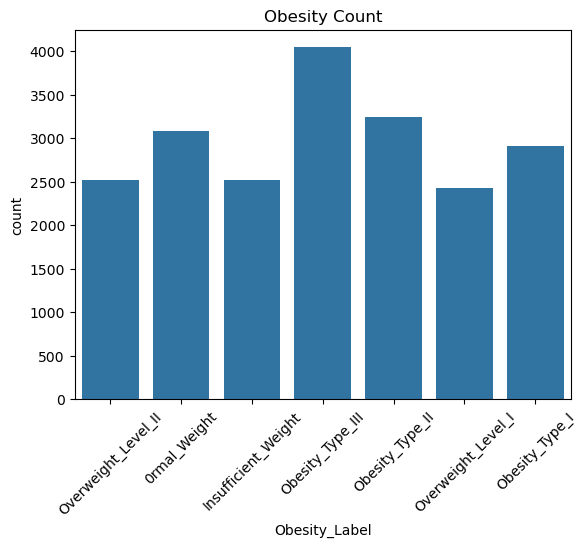

In [12]:
sns.countplot(x='Obesity_Label', data=df)
plt.xticks(rotation=45)
plt.title("Obesity Count")
plt.show()

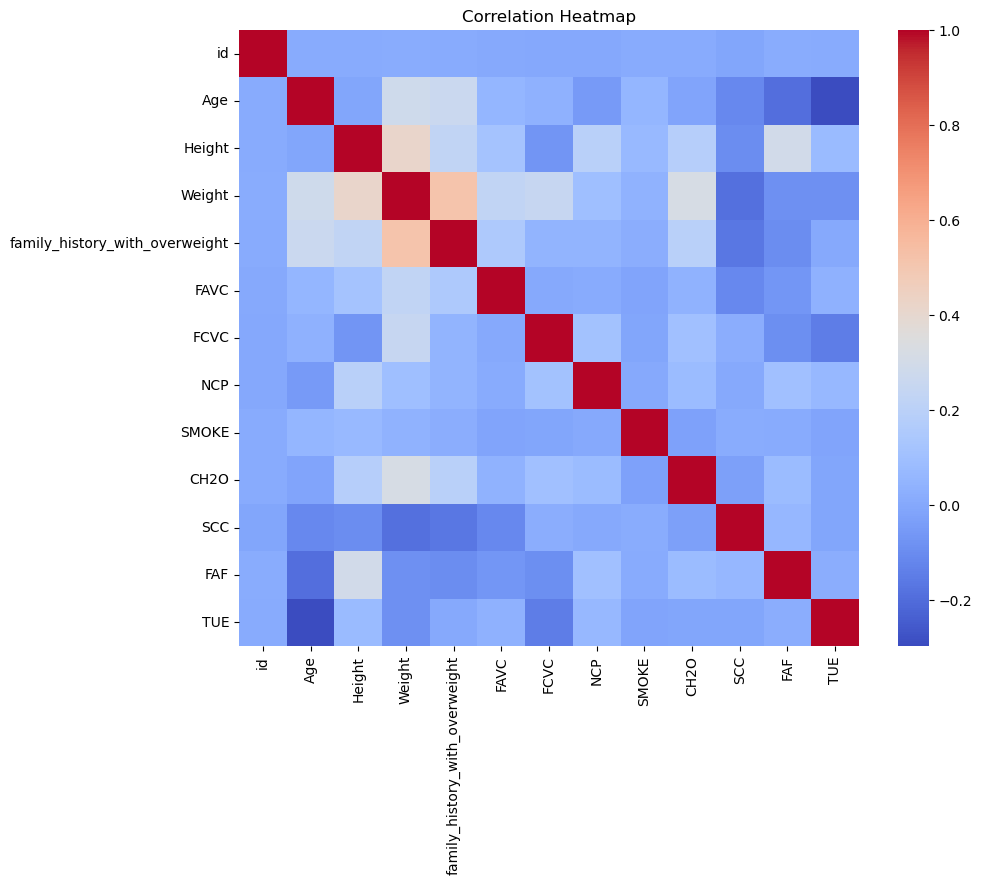

In [13]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [21]:
from sklearn.model_selection import train_test_split

X = df.drop(['0be1dad', 'Obesity_Label'], axis=1)
y = df['0be1dad']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score

print("Decision Tree:", accuracy_score(y_test, y_pred_dt))

Decision Tree: 0.8436897880539499


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score

print("Random Forest:", accuracy_score(y_test, y_pred_rf))


Random Forest: 0.8973988439306358


In [27]:
from sklearn.metrics import accuracy_score

print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Decision Tree: 0.8436897880539499
Random Forest: 0.8973988439306358


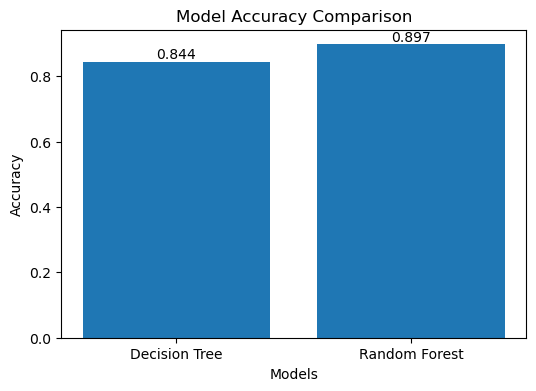

In [28]:
import matplotlib.pyplot as plt

# Store accuracies
models = ['Decision Tree', 'Random Forest']
accuracies = [
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

# Plot
plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

# Show values on bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, str(round(v, 3)), ha='center')

plt.show()

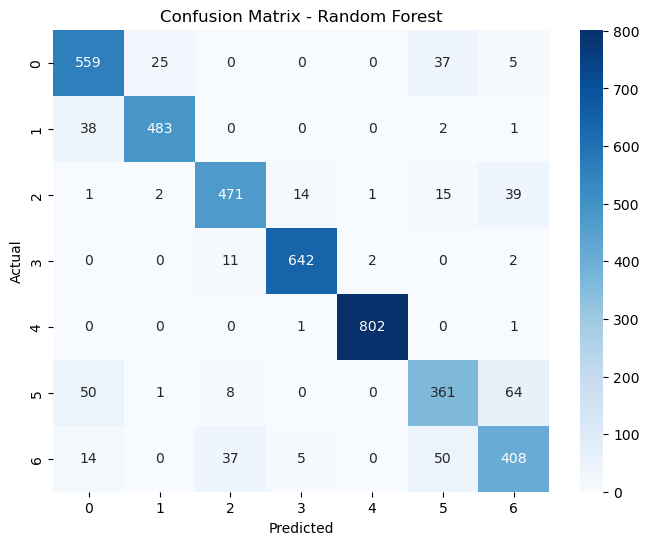

In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

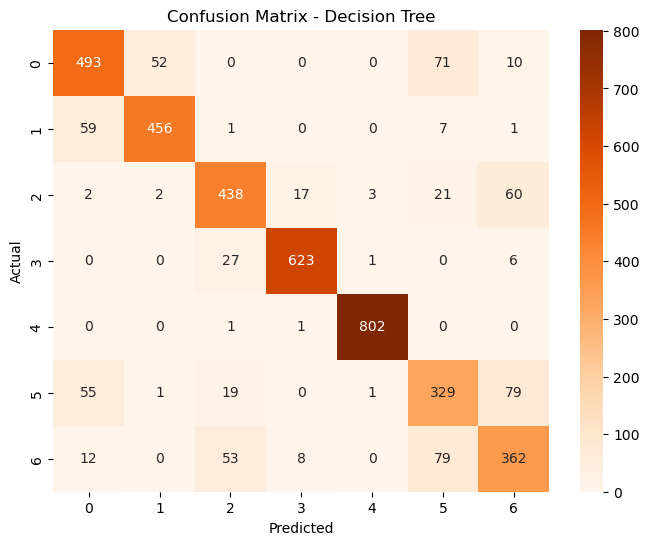

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8,6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges')

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

In [32]:
y_pred_best = best_model.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))

Tuned Accuracy: 0.8978805394990366


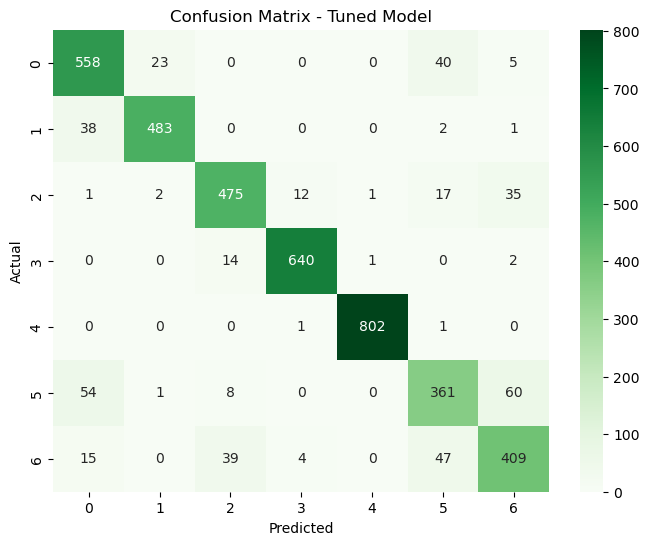

In [33]:
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8,6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens')

plt.title("Confusion Matrix - Tuned Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

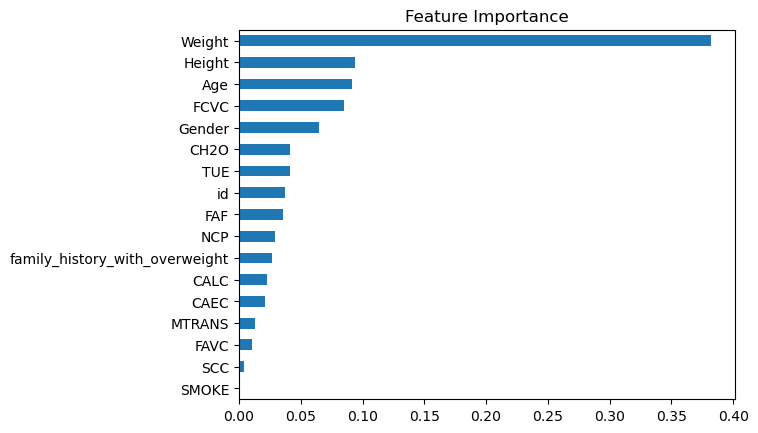

In [34]:
feature_importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

feature_importances.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

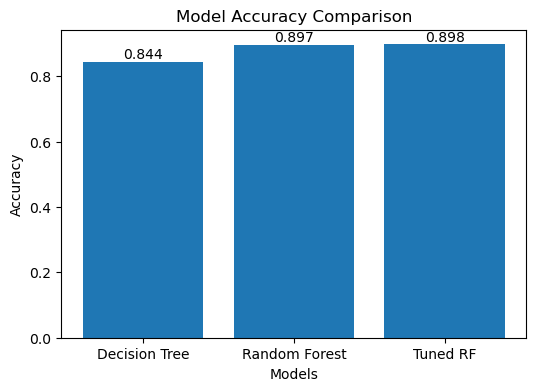

In [35]:
models = ['Decision Tree', 'Random Forest', 'Tuned RF']
accuracies = [
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_best)
]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, str(round(v, 3)), ha='center')

plt.show()

## Comparison with Kaggle Notebook

The original Kaggle notebook provides a basic implementation of obesity prediction using machine learning techniques. It mainly focuses on applying a single model with minimal visualization and limited evaluation.

In contrast, this project enhances the overall workflow by improving code structure, adding multiple models, and performing detailed analysis.

Key differences include:

- Kaggle notebook uses a basic model implementation, while this project uses multiple models such as Decision Tree and Random Forest.
- Limited visualization in Kaggle, whereas this project includes pie charts, count plots, and heatmaps for better understanding of data.
- Kaggle notebook lacks detailed evaluation, while this project includes confusion matrices for each model.
- No clear comparison of models in Kaggle, while this project compares performance using accuracy graphs.
- Hyperparameter tuning is either missing or minimal in Kaggle, whereas this project uses GridSearchCV for optimization.

Overall, this project provides a more structured, detailed, and improved approach compared to the Kaggle notebook.

## Improvements Made

The following improvements have been implemented over the Kaggle notebook:

1. Data Visualization:
   - Added pie chart to show obesity distribution.
   - Added count plot for category comparison.
   - Added correlation heatmap to understand feature relationships.

2. Multiple Model Implementation:
   - Implemented both Decision Tree and Random Forest models.
   - Compared their performance instead of relying on a single model.

3. Model Evaluation:
   - Added confusion matrix for Decision Tree, Random Forest, and tuned model.
   - Provided better insight into model performance.

4. Hyperparameter Tuning:
   - Applied GridSearchCV to optimize Random Forest parameters.
   - Improved model accuracy after tuning.

5. Feature Importance:
   - Identified important features affecting obesity prediction.
   - Visualized feature importance using bar graph.

6. Accuracy Comparison:
   - Created bar chart comparing accuracy of different models.
   - Clearly shows performance improvement.

7. Code Structure Improvement:
   - Organized code into clear steps (EDA, preprocessing, modeling, evaluation).
   - Improved readability and understanding.

These improvements make the project more comprehensive, accurate, and easier to interpret.

## Conclusion

In this project, obesity levels were predicted using machine learning techniques based on lifestyle and health-related features. Multiple models such as Decision Tree and Random Forest were implemented and evaluated.

The Random Forest model performed better than the Decision Tree model, and further improvement was achieved through hyperparameter tuning. Visualization techniques helped in better understanding of the dataset and feature relationships.

Compared to the Kaggle notebook, this project provides a more detailed analysis, improved model performance, and better visualization. The addition of evaluation metrics and feature importance makes the model more reliable and interpretable.

Thus, the project successfully demonstrates how machine learning can be used to predict obesity levels and improve decision-making.